# ***✅ Project Title***
### ***Smartphone Addiction Prediction System***

## ***🎯 Objective***
### ***Predict whether a person is addicted to smartphone or not using usage behavior.***

In [ ]:
# Drive Mount
# For Giving Access of files to google colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
filepath ="/content/drive/MyDrive/Machine Learning with Python/Smartphone Addiction Prediction System/Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv"

In [ ]:
#importing Libraries
import pandas as pd

In [ ]:
#From here we start EDA (Exploratory Data Analysis)
#storing our data in the 'data' varible
data = pd.read_csv(filepath)

In [ ]:
## This Will display by default 5 top rows of data
data.head()

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


In [ ]:
#Checking Columns in Data
data.columns

Index(['transaction_id', 'user_id', 'age', 'gender', 'daily_screen_time_hours',
       'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours',
       'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time',
       'stress_level', 'academic_work_impact', 'addiction_level',
       'addicted_label'],
      dtype='object')

In [ ]:
## This will display total rows and total columns in data
data.shape

(7500, 16)

In [ ]:
#Checking Information of Data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   object 
 1   user_id                  7500 non-null   object 
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   object 
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   object 
 13  academic_work_impact     7500 non-null   object 
 14  addiction_level         

In [ ]:
## Checking How many Null Values in all columns
## isnull() is used to check null Values and sum() is used to calculate total null values
data.isnull().sum()

,0
transaction_id,0
user_id,0
age,0
gender,0
daily_screen_time_hours,0
social_media_hours,0
gaming_hours,0
work_study_hours,0
sleep_hours,0
notifications_per_day,0


In [ ]:
#Dropping "addiction_level" Column
data.drop(columns=['addiction_level'], inplace=True)

***"addiction_level was closely related to the target variable addicted_label, which could cause data leakage. To ensure the model learns genuine patterns rather than direct indicators, I removed it."***

### ***Checking for duplicate values in data***

In [ ]:
#Now we are checking is there any duplicate values in our data or not
print(data.duplicated().sum())

0


### ***Checking unique values***

In [ ]:
for col in data:
  print(col)
  print(data[col].unique())
  print("*******************************")
  print("*******************************")

transaction_id
['TXN00001' 'TXN00002' 'TXN00003' ... 'TXN07498' 'TXN07499' 'TXN07500']
*******************************
*******************************
user_id
['U00001' 'U00002' 'U00003' ... 'U07498' 'U07499' 'U07500']
*******************************
*******************************
age
[21 24 31 32 25 26 35 34 27 33 19 18 20 28 22 23 29 30]
*******************************
*******************************
gender
['Male' 'Other' 'Female']
*******************************
*******************************
daily_screen_time_hours
[ 3.23  5.09  6.06  7.83  9.96  9.32 10.4   4.26  4.38  9.76  8.48  5.16
 11.52  4.09 10.74  3.87  4.71 10.52 11.87 11.72 10.66  5.85  3.66  3.07
  9.46  9.94  4.33 10.96 10.04  6.15  6.6   6.11  9.18  9.    5.73  5.55
 11.86  8.9  11.26  7.05  6.02  4.86  7.84 10.56  3.45  9.74  5.15  8.21
 10.65 10.43  9.48  5.76  5.07  8.37  5.63  5.27  4.07  8.49  7.9   9.2
  5.06 11.97  5.59  4.69 11.76  7.49  9.72 10.79  3.39  3.9  10.67 11.98
 10.17  8.75  3.2   4.97  8.22 11.2

### ***Checking Total value-counts of all columns***

In [ ]:
for col in data:
  print(data[col].value_counts())
  print("*******************************")
  print("*******************************")

transaction_id
TXN07500    1
TXN00001    1
TXN00002    1
TXN00003    1
TXN00004    1
           ..
TXN00017    1
TXN00016    1
TXN00015    1
TXN00014    1
TXN00013    1
Name: count, Length: 7500, dtype: int64
*******************************
*******************************
user_id
U07500    1
U00001    1
U00002    1
U00003    1
U00004    1
         ..
U00017    1
U00016    1
U00015    1
U00014    1
U00013    1
Name: count, Length: 7500, dtype: int64
*******************************
*******************************
age
31    461
21    443
20    440
32    433
33    432
27    431
26    429
29    427
34    418
35    415
23    413
30    410
25    408
19    400
18    399
22    396
24    376
28    369
Name: count, dtype: int64
*******************************
*******************************
gender
Male      2553
Other     2486
Female    2461
Name: count, dtype: int64
*******************************
*******************************
daily_screen_time_hours
8.13     18
5.75     17
5.09     17
6.22   

## ***Data Visualization***

### ***Uni-Variate Analysis***

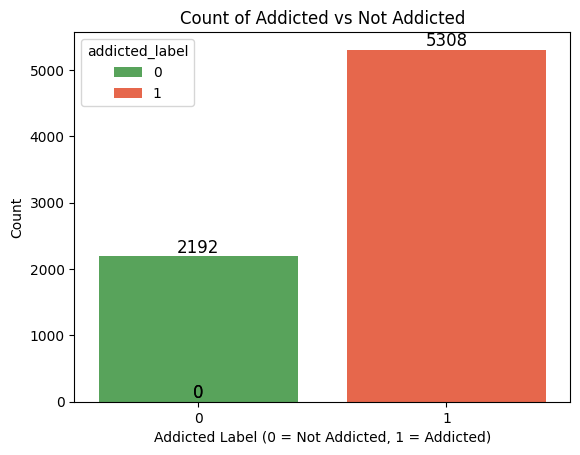

In [ ]:
#CountPlot
import seaborn as sns
import matplotlib.pyplot as plt

ax = sns.countplot(x='addicted_label', data=data, hue="addicted_label",palette=['#4CAF50', '#FF5733'])

# Add counts on top
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, color='black')

plt.title("Count of Addicted vs Not Addicted")
plt.xlabel("Addicted Label (0 = Not Addicted, 1 = Addicted)")
plt.ylabel("Count")
plt.show()

***The plot shows the number of addicted and non-addicted users, helping to identify whether the dataset is balanced, which is crucial for model performance.***

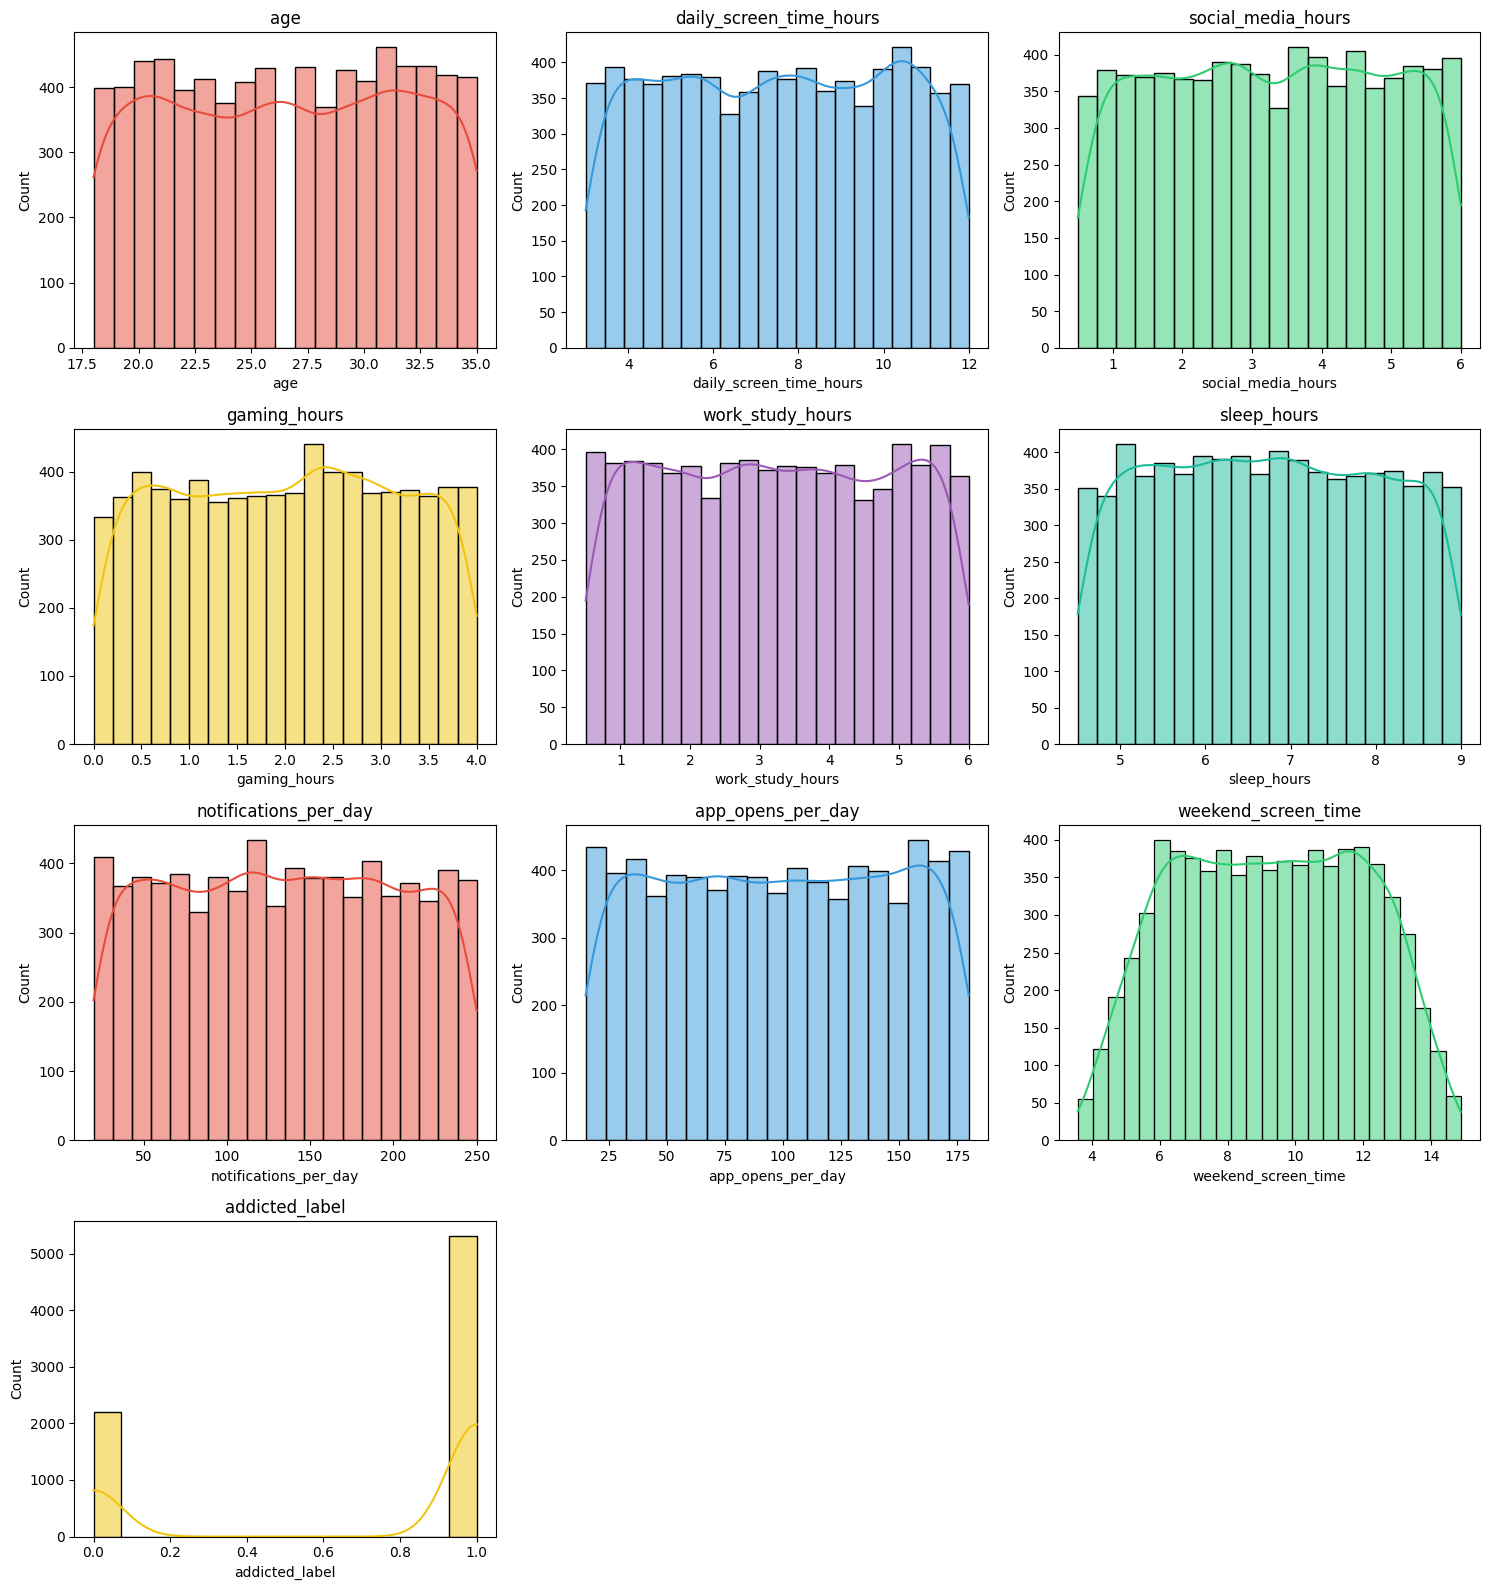

In [ ]:
#Histogram of all columns
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = data.select_dtypes(include=['int64','float64']).columns

colors = ['#e74c3c', '#3498db', '#2ecc71', '#f1c40f', '#9b59b6', '#1abc9c']

cols = 3  # number of plots per row
rows = (len(num_cols) + cols - 1) // cols

plt.figure(figsize=(15, rows * 4))

for i, col in enumerate(num_cols):
    plt.subplot(rows, cols, i + 1)
    sns.histplot(data[col], kde=True, color=colors[i % len(colors)], edgecolor='black')
    plt.title(col)

plt.tight_layout()
plt.show()

***The distributions indicate that most users have moderate usage patterns, with some showing extreme behavior, which can be important for identifying smartphone addiction.***

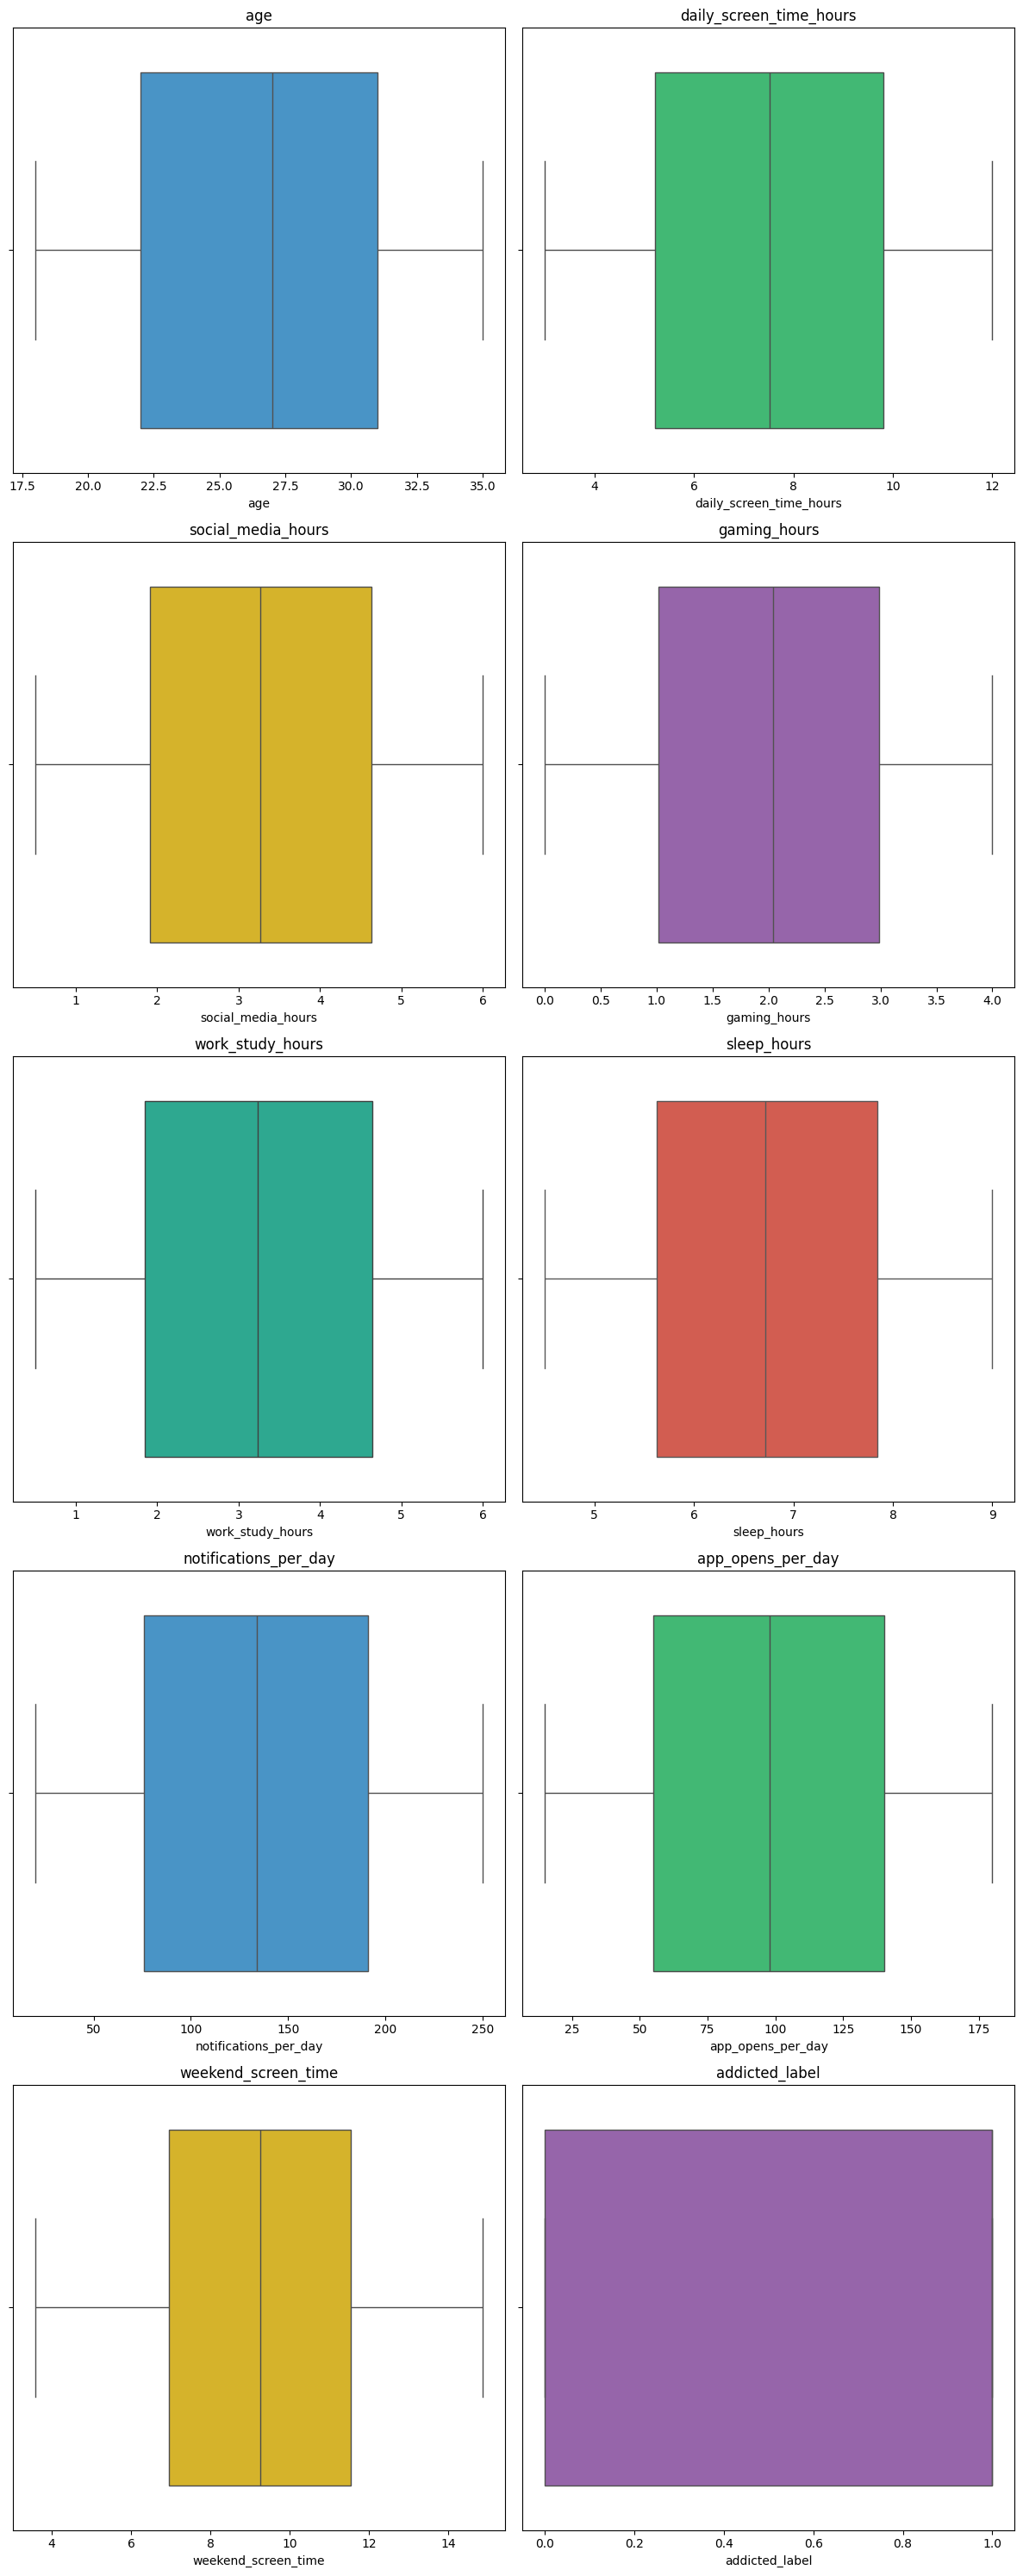

In [ ]:
#Ploting Boxplot for checking Outliers of all columns
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = data.select_dtypes(include=['int64','float64']).columns

colors = ['#e74c3c', '#3498db', '#2ecc71', '#f1c40f', '#9b59b6', '#1abc9c']

plt.figure(figsize=(12, len(num_cols)*3))

for i, col in enumerate(num_cols, 1):
    plt.subplot(len(num_cols)//2 + len(num_cols)%2, 2, i)
    sns.boxplot(x=data[col], color=colors[i % len(colors)])
    plt.title(f"{col}")

plt.tight_layout()
plt.show()

### ***After ploting boxplot i analyze that there is no any outliers in data***

## ***Bi-Variate Analysis***

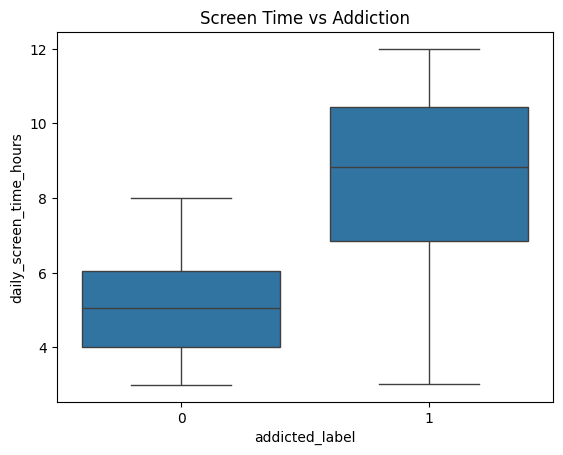

In [ ]:
#Screen Time vs Addiction
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(x='addicted_label', y='daily_screen_time_hours', data=data)
plt.title("Screen Time vs Addiction")
plt.show()

***Addicted users have noticeably higher screen time compared to non-addicted users, indicating that screen time is a key factor influencing smartphone addiction.***

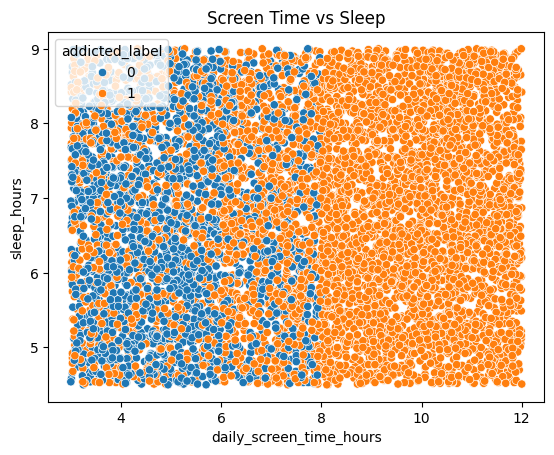

In [ ]:
#Scatter Plot
sns.scatterplot(x='daily_screen_time_hours',
                y='sleep_hours',
                hue='addicted_label',
                data=data)
plt.title("Screen Time vs Sleep")
plt.show()

***The plot indicates that higher screen time is associated with lower sleep hours, and addicted users are mostly concentrated in this region, highlighting a strong negative relationship between screen usage and sleep.***

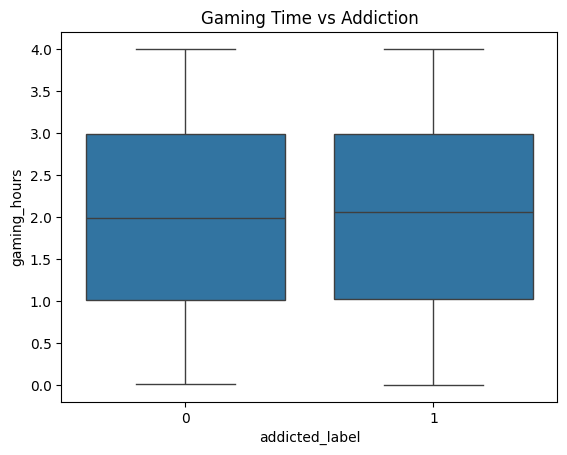

In [ ]:
#Gaming Time vs Addiction
sns.boxplot(x='addicted_label', y='gaming_hours', data=data)
plt.title("Gaming Time vs Addiction")
plt.show()

***Gaming hours show minimal difference between groups, suggesting it is not a strong indicator of addiction.***

In [ ]:
#Dropping some columns
#Because we keepn them then
#Model may overfit
#Learns random patterns
#Reduces real accuracy
data = data.drop(columns=['transaction_id', 'user_id'])

In [ ]:
#Used LabelEncoder for converting categorical data to numerical values
from sklearn.preprocessing import LabelEncoder

# Create separate encoders
le_gender = LabelEncoder()
le_stress = LabelEncoder()
le_academic = LabelEncoder()

# Apply encoding
data['gender'] = le_gender.fit_transform(data['gender'])
data['stress_level'] = le_stress.fit_transform(data['stress_level'])
data['academic_work_impact'] = le_academic.fit_transform(data['academic_work_impact'])

In [ ]:
data.head()

,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addicted_label
0,21,1,3.23,2.01,0.89,4.55,7.55,248,154,3.95,2,1,0
1,24,2,5.09,3.81,2.24,4.44,7.66,127,71,6.71,2,1,0
2,31,2,6.06,1.36,3.83,2.35,4.92,44,106,8.68,0,0,0
3,32,2,7.83,5.85,1.51,3.54,8.23,178,107,9.77,0,1,1
4,25,1,9.96,5.92,3.42,5.27,6.21,136,177,12.55,1,0,1


## ***Multi-Variate Analysis***

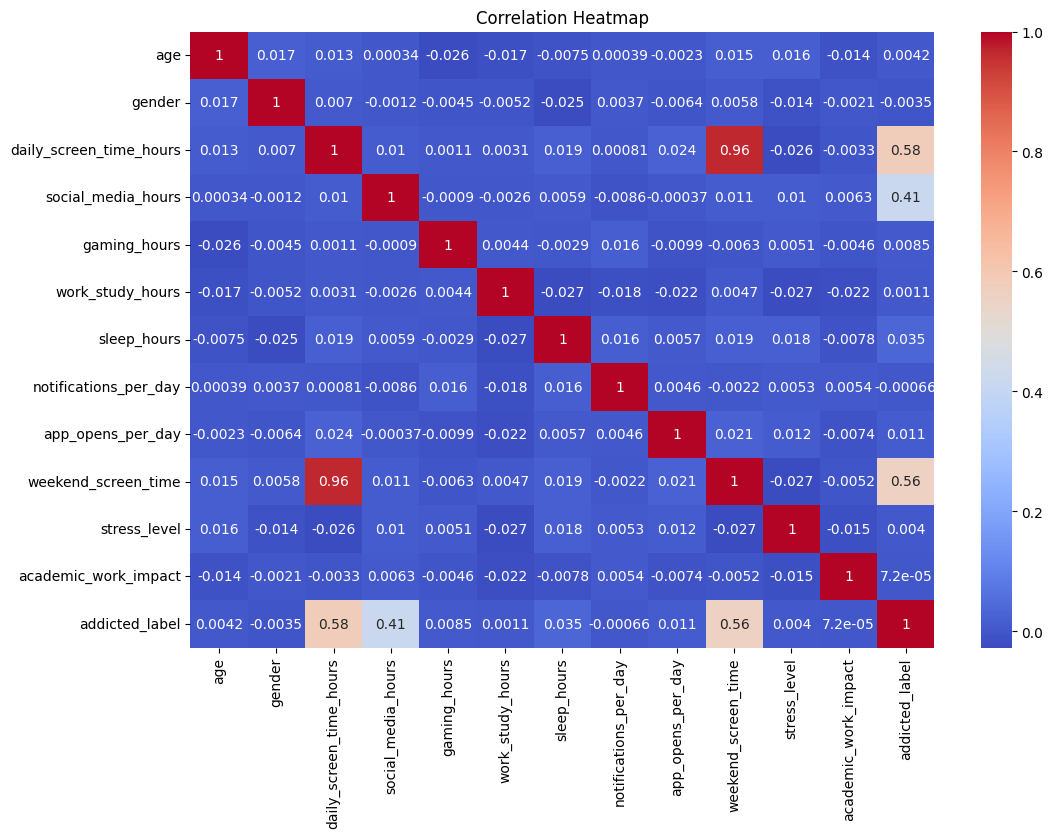

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

***The heatmap shows relationships between all numerical features. Screen time, social media usage, and notifications show positive correlation with addiction, while sleep hours show a negative correlation. This indicates that higher usage and lower sleep are key indicators of smartphone addiction.***

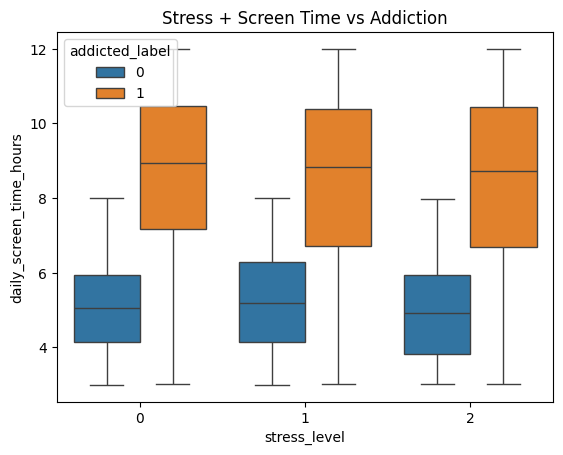

In [ ]:
#Boxplot with Multiple Factors
sns.boxplot(x='stress_level',
            y='daily_screen_time_hours',
            hue='addicted_label',
            data=data)
plt.title("Stress + Screen Time vs Addiction")
plt.show()

***Users with higher stress levels and higher screen time tend to show more addiction. This indicates that both psychological and behavioral factors together influence smartphone addiction.***

# ***Splitting Data into 2 Parts***

In [ ]:
#Here our target values is addicted_label
x = data.drop("addicted_label",axis=1)
y = data["addicted_label"]

In [ ]:
#Futher splitting into train test
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.3,random_state=42)

### ***Appying all model to train and  test***

### ***1st LogistricRegression***

In [ ]:
#importing libraries

from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(x_train,y_train)

#Taking prediction from data
pred_lr = lr.predict(x_test)

#Checking Accuracy
from sklearn.metrics import accuracy_score
acc_lr = accuracy_score(y_test,pred_lr)
print(acc_lr)

0.8697777777777778


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


#### ***Ploting confusion Matrix***

[[ 491  182]
 [ 111 1466]]


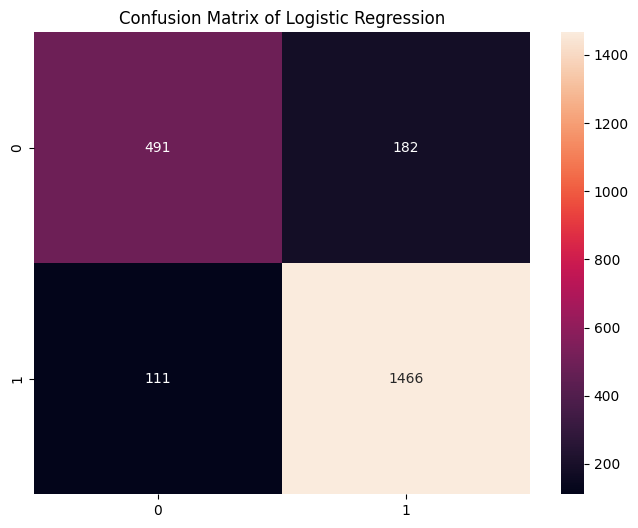

In [ ]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix
cm_lr = confusion_matrix(y_test,pred_lr)
print(cm_lr)

#Visualizing cm
plt.figure(figsize=(8,6))
sns.heatmap(cm_lr,annot=True,fmt="d")
plt.title("Confusion Matrix of Logistic Regression")
plt.show()


***The model correctly predicted 491 non-addicted users and 1466 addicted users. However, it misclassified 182 non-addicted users as addicted and 111 addicted users as non-addicted. Overall, the number of correct predictions is significantly higher than the misclassifications, indicating that the model performs well in identifying smartphone addiction, though there is still some scope for improvement.***

## ***2nd Model Decision Tree classifier Model***

In [ ]:
#Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier
dtc = DecisionTreeClassifier()
dtc.fit(x_train,y_train)

pred_dtc = dtc.predict(x_test)

acc_dtc = accuracy_score(y_test,pred_dtc)
print(acc_dtc)

0.9226666666666666


## ***3rd Random Forest Classifier Model***

In [ ]:
#Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier()
rfc.fit(x_train,y_train)

pred_rfc = rfc.predict(x_test)

acc_rfc = accuracy_score(y_test,pred_rfc)
print(acc_rfc)

0.9257777777777778


## ***4th XGBoost Classifier***

In [ ]:
#xgboost classifier

from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb.fit(x_train,y_train)

pred_xgb = xgb.predict(x_test)

acc_xgb = accuracy_score(y_test,pred_xgb)
print(acc_xgb)

0.9311111111111111


## ***XGBoost achieved the highest accuracy and was selected as the final model for prediction.***

**"XGBoost performed better than other models because it uses boosting, which combines multiple weak learners to improve prediction accuracy and handle complex patterns effectively."**

## ***Downloading Model***

In [ ]:
#Importing Liraries for Downloading Models
import joblib
joblib.dump(xgb,"Smartphone_Addiction_Prediction_System.pkl")

from google.colab import files
files.download("Smartphone_Addiction_Prediction_System.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
joblib.dump(LabelEncoder(),"le_gender.pkl")
joblib.dump(LabelEncoder(),"le_stress.pkl")
joblib.dump(LabelEncoder(),"le_academic.pkl")

files.download('le_gender.pkl')
files.download('le_stress.pkl')
files.download('le_academic.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>